# Repaso: Vectores y Matrices

Este notebook es un repaso general de álgebra lineal: vectores y matrices, sus propiedades y operaciones básicas. Nos va a servir como base para los temas del curso (por ejemplo, redes de Hopfield y memoria hebbiana), pero acá nos enfocamos solo en la matemática.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

---
# Parte 1: Vectores

## 1.1 ¿Qué es un vector? Definición y propiedades

Un **vector** es una lista ordenada de números. Cada número es una **componente** del vector.

$$\vec{v} = \begin{pmatrix} v_1 \\ v_2 \end{pmatrix}$$

Geométricamente, un vector en 2D se puede pensar como una flecha que va desde el origen $(0,0)$ hasta el punto $(v_1, v_2)$.

Dos propiedades básicas de un vector:
- **Magnitud** (o norma): qué tan largo es. Se calcula como $\|\vec{v}\| = \sqrt{v_1^2 + v_2^2}$.
- **Dirección**: hacia dónde apunta.

Vector v: [3 2]
Magnitud de v: 3.605551275463989


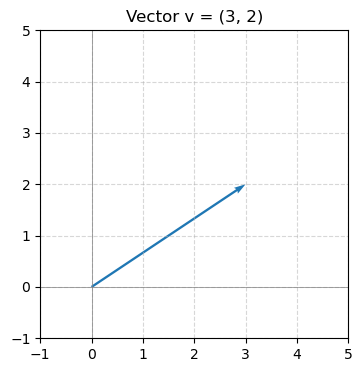

In [ ]:
v = np.array([3, 2])

magnitud = np.linalg.norm(v)
print("Vector v:", v)
print("Magnitud de v:", magnitud)

# Lo graficamos como una flecha desde el origen
plt.figure(figsize=(4, 4))
plt.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='tab:blue')
plt.xlim(-1, 5)
plt.ylim(-1, 5)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().set_aspect('equal')
plt.title("Vector v = (3, 2)")
plt.show()

## 1.2 Operaciones con vectores: combinación lineal

Las dos operaciones básicas entre vectores son la **suma** y la **multiplicación por un escalar** (un número).

- Suma: se suman componente a componente.
- Multiplicación por escalar: se multiplica cada componente por ese número (alarga, acorta o invierte el vector).

Una **combinación lineal** de dos vectores $\vec{v}_1$ y $\vec{v}_2$ es cualquier vector que se pueda escribir como

$$a\,\vec{v}_1 + b\,\vec{v}_2$$

para algunos números $a$ y $b$.

v1 = [3 1]  v2 = [1 2]
2*v1 + -1*v2 = [5 0]


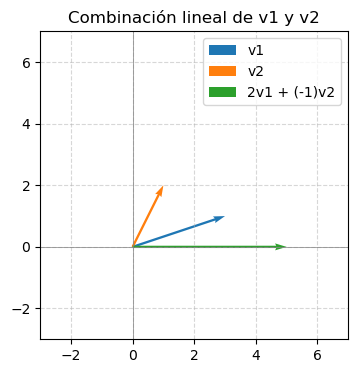

In [ ]:
v1 = np.array([3, 1])
v2 = np.array([1, 2])

a, b = 2, -1
combinacion = a * v1 + b * v2
print("v1 =", v1, " v2 =", v2)
print(f"{a}*v1 + {b}*v2 =", combinacion)

plt.figure(figsize=(4, 4))
plt.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='tab:blue', label='v1')
plt.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='tab:orange', label='v2')
plt.quiver(0, 0, combinacion[0], combinacion[1], angles='xy', scale_units='xy', scale=1, color='tab:green', label=f'{a}v1 + ({b})v2')
plt.xlim(-3, 7)
plt.ylim(-3, 7)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().set_aspect('equal')
plt.legend()
plt.title("Combinación lineal de v1 y v2")
plt.show()

## 1.3 Espacio de vectores: vectores base

Un conjunto de vectores **base** es un conjunto mínimo de vectores a partir del cual se puede construir, mediante combinaciones lineales, cualquier otro vector del espacio.

En 2D, la base más simple es la **base estándar**:

$$\hat{e}_1 = \begin{pmatrix} 1 \\ 0 \end{pmatrix}, \qquad \hat{e}_2 = \begin{pmatrix} 0 \\ 1 \end{pmatrix}$$

Cualquier vector $\vec{v} = (v_1, v_2)$ se puede escribir como combinación lineal de esta base: $\vec{v} = v_1 \hat{e}_1 + v_2 \hat{e}_2$.

In [ ]:
e1 = np.array([1, 0])
e2 = np.array([0, 1])

v = np.array([3, 2])
reconstruido = v[0] * e1 + v[1] * e2

print("v =", v)
print("v[0]*e1 + v[1]*e2 =", reconstruido)
print("¿Coinciden?", np.array_equal(v, reconstruido))

v = [3 2]
v[0]*e1 + v[1]*e2 = [3 2]
¿Coinciden? True


## 1.4 El producto punto (dot product)

El **producto punto** entre dos vectores se calcula multiplicando las componentes correspondientes y sumando los resultados:

$$\vec{a} \cdot \vec{b} = \sum_i a_i b_i$$

Geométricamente, el producto punto está relacionado con el ángulo entre los dos vectores y con cuánto "se parecen" en dirección:

- Si apuntan en direcciones parecidas → producto punto grande y positivo.
- Si son perpendiculares → producto punto igual a cero.
- Si apuntan en direcciones opuestas → producto punto negativo.

In [ ]:
a = np.array([3, 1])
b = np.array([1, 2])

producto_punto = np.dot(a, b)
print("a =", a, " b =", b)
print("a · b =", producto_punto)

# El producto punto también nos permite calcular el ángulo entre los vectores
cos_theta = producto_punto / (np.linalg.norm(a) * np.linalg.norm(b))
angulo = np.degrees(np.arccos(cos_theta))
print(f"Ángulo entre a y b: {angulo:.1f} grados")

a = [3 1]  b = [1 2]
a · b = 5
Ángulo entre a y b: 45.0 grados


---
# Parte 2: Matrices

## 2.1 Introducción a matrices

Una **matriz** es un arreglo rectangular de números, organizado en filas y columnas. Una forma útil de pensarla: una matriz de $m \times n$ es un conjunto de $n$ vectores columna, cada uno con $m$ componentes.

In [ ]:
A = np.array([
    [2, 0],
    [1, 3]
])
print("Matriz A (forma", A.shape, "):")
print(A)

print("\nColumna 0 de A:", A[:, 0])
print("Columna 1 de A:", A[:, 1])

Matriz A (forma (2, 2) ):
[[2 0]
 [1 3]]

Columna 0 de A: [2 1]
Columna 1 de A: [0 3]


## 2.2 Sistemas de ecuaciones

Un sistema de ecuaciones lineales se puede escribir de forma compacta como $A\vec{x} = \vec{b}$, donde $A$ es la matriz de coeficientes, $\vec{x}$ es el vector de incógnitas y $\vec{b}$ es el vector de resultados.

Por ejemplo, el sistema

$$2x_1 = 4$$
$$x_1 + 3x_2 = 7$$

se escribe como $A\vec{x} = \vec{b}$ con la matriz $A$ de arriba y $\vec{b} = (4, 7)$.

In [ ]:
b = np.array([4, 7])

x = np.linalg.solve(A, b)
print("Solución x:", x)
print("Verificación A @ x:", A @ x, " (debería dar", b, ")")

Solución x: [2.         1.66666667]
Verificación A @ x: [4. 7.]  (debería dar [4 7] )


## 2.3 Transformaciones lineales

Una matriz también se puede pensar como una **función** que transforma vectores: al multiplicar $A\vec{v}$, la matriz mueve al vector $\vec{v}$ a una nueva posición.

Veamos cómo la matriz $A$ transforma los vectores base $\hat{e}_1$ y $\hat{e}_2$ que vimos antes.

A @ e1 = [2 1]
A @ e2 = [0 3]


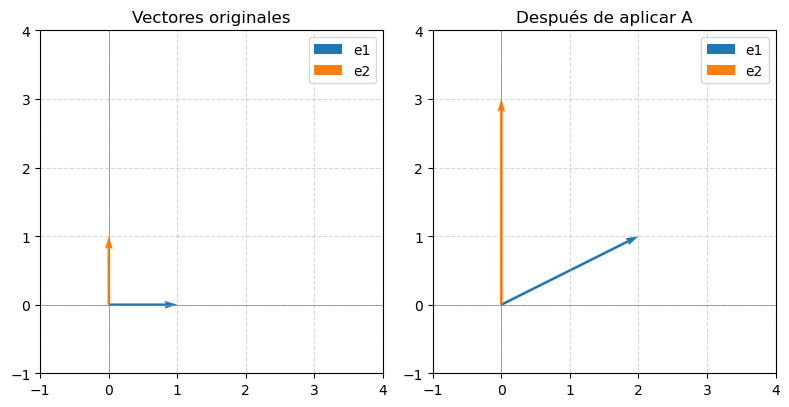

In [ ]:
e1_transformado = A @ e1
e2_transformado = A @ e2

print("A @ e1 =", e1_transformado)
print("A @ e2 =", e2_transformado)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for ax, (v1_, v2_, titulo) in zip(
    axes,
    [(e1, e2, "Vectores originales"), (e1_transformado, e2_transformado, "Después de aplicar A")]
):
    ax.quiver(0, 0, v1_[0], v1_[1], angles='xy', scale_units='xy', scale=1, color='tab:blue', label='e1')
    ax.quiver(0, 0, v2_[0], v2_[1], angles='xy', scale_units='xy', scale=1, color='tab:orange', label='e2')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 4)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_aspect('equal')
    ax.set_title(titulo)
    ax.legend()

plt.tight_layout()
plt.show()

Como se ve, la matriz $A$ estiró y desplazó los vectores base. Esta es la idea central detrás de una transformación lineal: la matriz define cómo se estira, rota o refleja el espacio.

## 2.4 Multiplicación de matrices

Multiplicar dos matrices equivale a **componer dos transformaciones**: primero se aplica una, después la otra.

Para que $A \cdot B$ esté definido, el número de columnas de $A$ tiene que ser **igual** al número de filas de $B$. El elemento $(i,j)$ del resultado es el producto punto entre la fila $i$ de $A$ y la columna $j$ de $B$.

Matemáticamente:

$$\mathbf C = \mathbf A \cdot \mathbf B$$

Luego

$$C_{ij} = \sum_l A_{il} B_{lj} $$


In [ ]:
B = np.array([
    [0, -1],
    [1,  0]
])  # esta matriz rota los vectores 90 grados

AB = A @ B
BA = B @ A

print("A @ B =")
print(AB)
print("\nB @ A =")
print(BA)
print("\n¿A@B es igual a B@A?", np.array_equal(AB, BA))

A @ B =
[[ 0 -2]
 [ 3 -1]]

B @ A =
[[-1 -3]
 [ 2  0]]

¿A@B es igual a B@A? False


Un detalle importante: la multiplicación de matrices **no es conmutativa** en general ($A \cdot B \neq B \cdot A$), porque el orden en que se aplican las transformaciones importa. De hecho, puede que dicha comnutación no esté definida. Si por ejemplo tenemos $\mathbf A\in \mathbb R^{n\times m}$ y $\mathbf B\in \mathbb R^{m\times l}$, el producto

$$\mathbf A\cdot \mathbf B$$

está bien definido

Pero

$$\mathbf B\cdot \mathbf A$$

sólo está definido en el caso particular en que $n=l$.

---
## Resumen

| Concepto | Idea clave |
|---|---|
| Vector | Lista ordenada de números; magnitud y dirección |
| Combinación lineal | Sumar vectores escalados: $a\vec{v}_1 + b\vec{v}_2$ |
| Base | Conjunto mínimo de vectores que genera todo el espacio |
| Producto punto | Mide el parecido/ángulo entre dos vectores |
| Matriz | Arreglo de números; conjunto de vectores columna |
| Sistema de ecuaciones | $A\vec{x} = \vec{b}$ |
| Transformación lineal | $A\vec{v}$ mueve al vector $\vec{v}$ a una nueva posición |
| Multiplicación de matrices | Composición de dos transformaciones; no conmutativa |

Con estas herramientas ya tenemos la base necesaria para avanzar con los modelos del curso.